In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("customer_churn_sample.csv")

df.head()

,CustomerID,Gender,Age,TenureMonths,SubscriptionType,MonthlyCharges,TotalCharges,ContractType,SupportTickets,PaymentMethod,Churn
0,CUST-1001,Female,34,12,Basic,49.99,599.88,Month-to-Month,3,Credit Card,Yes
1,CUST-1002,Male,45,24,Pro,79.99,1919.76,One Year,1,Bank Transfer,No
2,CUST-1003,Female,29,6,Basic,49.99,299.94,Month-to-Month,5,UPI,Yes
3,CUST-1004,Male,52,36,Enterprise,149.99,5399.64,Two Year,0,Credit Card,No
4,CUST-1005,Female,41,8,Pro,79.99,639.92,Month-to-Month,4,Debit Card,Yes


In [2]:
df.shape

(15, 11)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        15 non-null     object 
 1   Gender            15 non-null     object 
 2   Age               15 non-null     int64  
 3   TenureMonths      15 non-null     int64  
 4   SubscriptionType  15 non-null     object 
 5   MonthlyCharges    15 non-null     float64
 6   TotalCharges      15 non-null     float64
 7   ContractType      15 non-null     object 
 8   SupportTickets    15 non-null     int64  
 9   PaymentMethod     15 non-null     object 
 10  Churn             15 non-null     object 
dtypes: float64(2), int64(3), object(6)
memory usage: 1.4+ KB


In [4]:
df.describe()

,Age,TenureMonths,MonthlyCharges,TotalCharges,SupportTickets
count,15.000000,15.000000,15.000000,15.000000,15.000000
mean,39.066667,18.800000,84.656667,2088.478667,2.533333
std,11.392144,14.333776,42.739521,2407.365767,1.922300
min,23.000000,2.000000,49.990000,99.980000,0.000000
25%,30.000000,7.000000,49.990000,449.910000,1.000000
50%,38.000000,15.000000,79.990000,1099.780000,2.000000
75%,47.000000,27.000000,114.990000,3209.730000,4.000000
max,60.000000,48.000000,149.990000,7199.520000,6.000000


In [7]:
print(df.columns.tolist())

['CustomerID', 'Gender', 'Age', 'TenureMonths', 'SubscriptionType', 'MonthlyCharges', 'TotalCharges', 'ContractType', 'SupportTickets', 'PaymentMethod', 'Churn']


In [8]:
df["Churn"].value_counts()

Churn
No     8
Yes    7
Name: count, dtype: int64

In [9]:
churn_rate = (df["Churn"] == "Yes").mean() * 100

print("Churn Rate:", churn_rate, "%")

Churn Rate: 46.666666666666664 %


In [11]:
avg_monthly_charges = df["MonthlyCharges"].mean()
avg_tenure = df["TenureMonths"].mean()

clv = avg_monthly_charges * avg_tenure

print("CLV:", clv)

CLV: 1591.5453333333337


In [14]:
mrr_loss = df.loc[df["Churn"] == "Yes", "MonthlyCharges"].sum()

print("MRR Loss:", mrr_loss)

MRR Loss: 409.93


In [15]:
contract_churn = df.groupby("ContractType")["Churn"].apply(
    lambda x: (x == "Yes").mean() * 100
)

print(contract_churn)

ContractType
Month-to-Month    100.0
One Year            0.0
Two Year            0.0
Name: Churn, dtype: float64


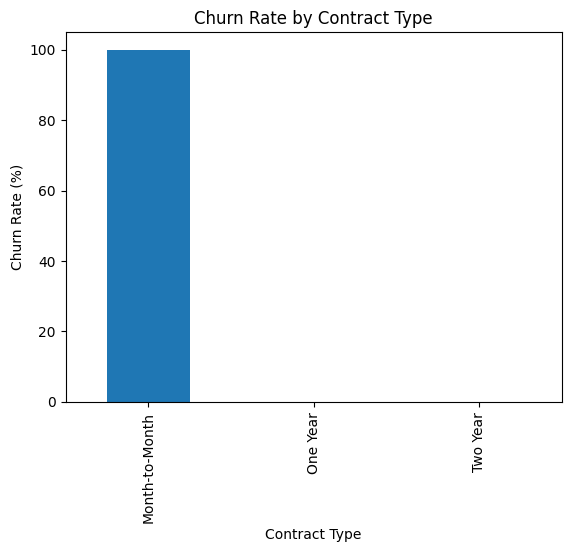

In [16]:
contract_churn.plot(kind="bar")

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.show()

In [18]:
bins = [0, 6, 12, 24, 100]
labels = ["0-6 Months", "7-12 Months", "13-24 Months", "25+ Months"]

df["tenure_group"] = pd.cut(
    df["TenureMonths"],
    bins=bins,
    labels=labels
)

In [19]:
tenure_churn = df.groupby("tenure_group", observed=False)["Churn"].apply(
    lambda x: (x == "Yes").mean() * 100
)

print(tenure_churn)

tenure_group
0-6 Months      100.0
7-12 Months     100.0
13-24 Months     20.0
25+ Months        0.0
Name: Churn, dtype: float64


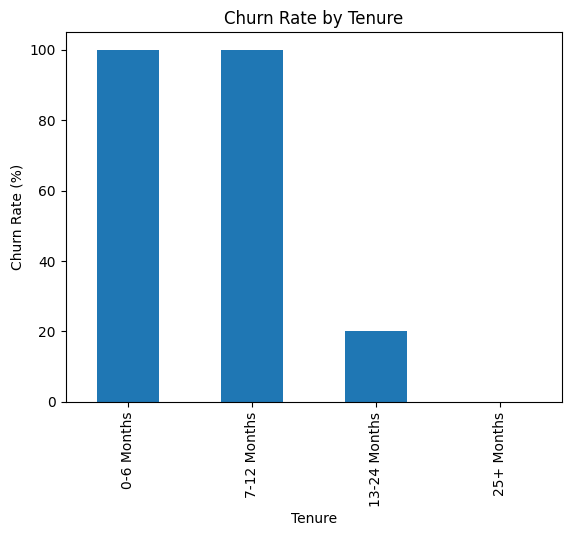

In [20]:
tenure_churn.plot(kind="bar")

plt.title("Churn Rate by Tenure")
plt.xlabel("Tenure")
plt.ylabel("Churn Rate (%)")
plt.show()

In [21]:
payment_churn = df.groupby("PaymentMethod")["Churn"].apply(
    lambda x: (x == "Yes").mean() * 100
)

print(payment_churn)

PaymentMethod
Bank Transfer      0.000000
Credit Card       33.333333
Debit Card       100.000000
UPI               75.000000
Name: Churn, dtype: float64


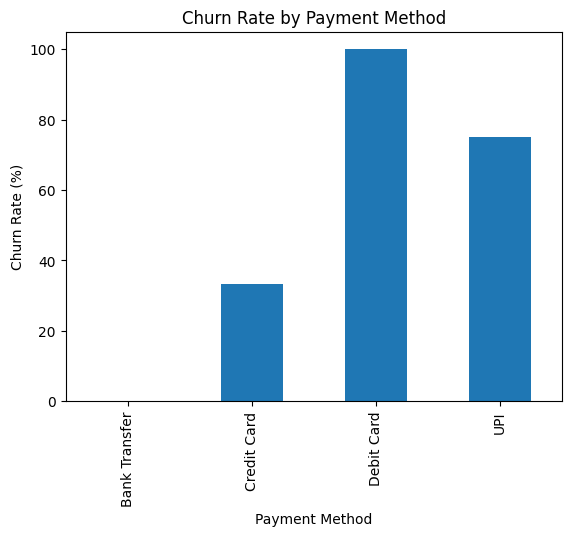

In [22]:
payment_churn.plot(kind="bar")

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.show()

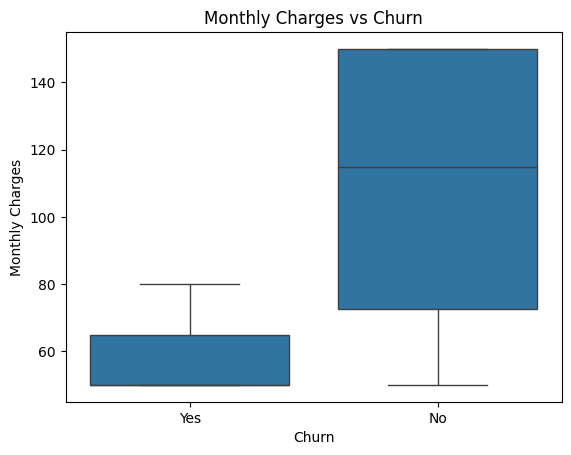

In [24]:
sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df
)

plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

In [26]:
numeric_data = df[
    ["Age",
     "TenureMonths",
     "MonthlyCharges",
     "TotalCharges",
     "SupportTickets"]
]

In [27]:
correlation = numeric_data.corr()

print(correlation)

                     Age  TenureMonths  MonthlyCharges  TotalCharges  \
Age             1.000000      0.850446        0.703486      0.759139   
TenureMonths    0.850446      1.000000        0.869103      0.955711   
MonthlyCharges  0.703486      0.869103        1.000000      0.951240   
TotalCharges    0.759139      0.955711        0.951240      1.000000   
SupportTickets -0.839999     -0.856506       -0.710592     -0.733568   

                SupportTickets  
Age                  -0.839999  
TenureMonths         -0.856506  
MonthlyCharges       -0.710592  
TotalCharges         -0.733568  
SupportTickets        1.000000  


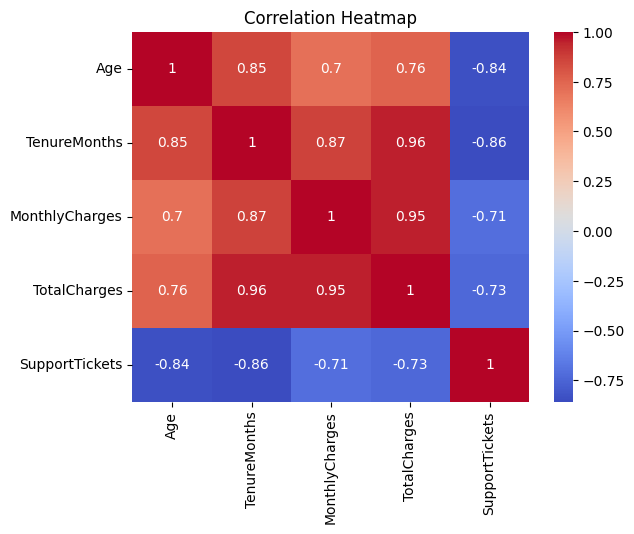

In [28]:
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

In [29]:
df.groupby("Churn")[[
    "Age",
    "TenureMonths",
    "MonthlyCharges",
    "SupportTickets"
]].mean()

,Age,TenureMonths,MonthlyCharges,SupportTickets
Churn,,,,
No,46.625000,29.125,107.490000,1.000000
Yes,30.428571,7.000,58.561429,4.285714
